In [5]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vjchoudhary7/customer-segmentation-tutorial-in-python")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.
Path to dataset files: /kaggle/input/customer-segmentation-tutorial-in-python


In [6]:
import os

# using data loaded in above cell

df = pd.read_csv(os.path.join(path, 'Mall_Customers.csv'))
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN, KMeans
from sklearn.datasets import make_moons
from sklearn.preprocessing import StandardScaler


In [7]:

X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

dbscan = DBSCAN(eps=12, min_samples=5)
labels = dbscan.fit_predict(X)

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print("Number of clusters:", n_clusters)
print("Number of noise points:", n_noise)


Number of clusters: 3
Number of noise points: 11


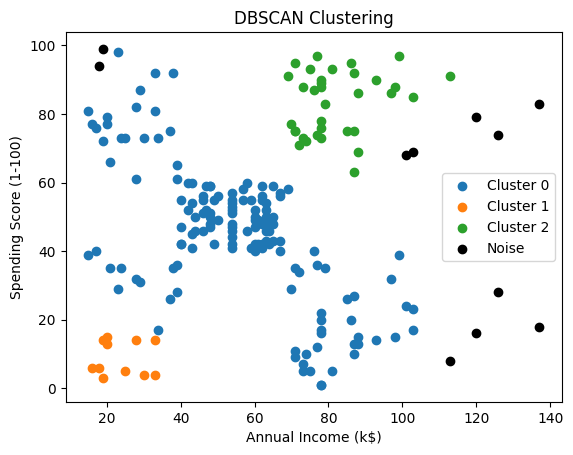

In [8]:

unique_labels = set(labels)

for label in unique_labels:
    mask = labels == label

    if label == -1:
        plt.scatter(X[mask].iloc[:,0], X[mask].iloc[:,1], c='black', label='Noise')
    else:
        plt.scatter(X[mask].iloc[:,0], X[mask].iloc[:,1], label=f'Cluster {label}')

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('DBSCAN Clustering')
plt.legend()
plt.show()


In [9]:

params = [
    (8,5),
    (15,3)
]

for eps, min_samples in params:
    db = DBSCAN(eps=eps, min_samples=min_samples)
    lbl = db.fit_predict(X)

    clusters = len(set(lbl)) - (1 if -1 in lbl else 0)
    noise = list(lbl).count(-1)

    print(f'eps={eps}, min_samples={min_samples}')
    print('Clusters:', clusters)
    print('Noise:', noise)
    print('-'*30)


eps=8, min_samples=5
Clusters: 6
Noise: 35
------------------------------
eps=15, min_samples=3
Clusters: 1
Noise: 0
------------------------------



### Summary

- Smaller eps usually creates more clusters and more noise points.
- Larger eps merges nearby groups and reduces noise.
- Larger min_samples makes DBSCAN stricter, increasing noise detection.
- Choosing good parameters is important because DBSCAN is highly sensitive to density settings.


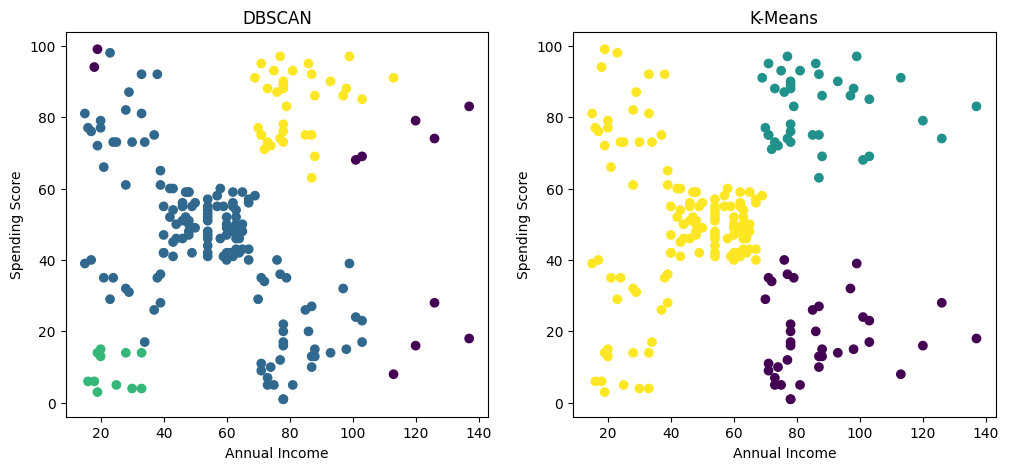

Observation: DBSCAN handles outliers and irregular cluster shapes better. K-Means assumes roughly spherical clusters and assigns every point to a cluster.


In [10]:

dbscan = DBSCAN(eps=12, min_samples=5)
db_labels = dbscan.fit_predict(X)

k = len(set(db_labels)) - (1 if -1 in db_labels else 0)

kmeans = KMeans(n_clusters=max(k,2), random_state=42, n_init=10)
km_labels = kmeans.fit_predict(X)

fig, ax = plt.subplots(1,2, figsize=(12,5))

ax[0].scatter(X.iloc[:,0], X.iloc[:,1], c=db_labels)
ax[0].set_title('DBSCAN')

ax[1].scatter(X.iloc[:,0], X.iloc[:,1], c=km_labels)
ax[1].set_title('K-Means')

for a in ax:
    a.set_xlabel('Annual Income')
    a.set_ylabel('Spending Score')

plt.show()

print("Observation: DBSCAN handles outliers and irregular cluster shapes better. K-Means assumes roughly spherical clusters and assigns every point to a cluster.")


Noise Point Indices:
[ 97 191]


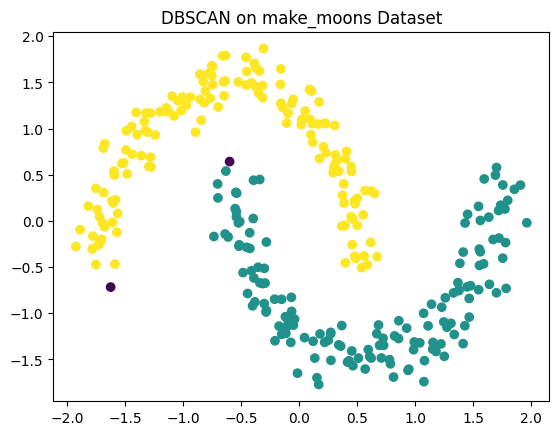

In [11]:

X_moons, y = make_moons(n_samples=300, noise=0.08, random_state=42)

X_scaled = StandardScaler().fit_transform(X_moons)

db = DBSCAN(eps=0.25, min_samples=5)
labels_moons = db.fit_predict(X_scaled)

noise_indices = np.where(labels_moons == -1)[0]

print("Noise Point Indices:")
print(noise_indices)

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=labels_moons)
plt.title("DBSCAN on make_moons Dataset")
plt.show()
